# **Notebook 8 – Decision Trees**

## **1. Decision Tree**

**Understand the Concept**

- A Decision Tree is a supervised learning algorithm.
- It can be used for Classification and Regression.
- It makes decisions by asking simple questions about the data.
- The data is split step by step until it reaches a final prediction.

**How It Works**

- The tree starts with a Root Node.
- It splits the data based on the best feature and condition.
- The process continues through Internal Nodes.
- Finally, it reaches a Leaf Node where the prediction is made.



## **2. Root Node**

**Understand the Concept**

- The Root Node is the first and top node of a Decision Tree.
- It contains the complete dataset before any splitting.
- The model selects the best feature for the first split.
- The Root Node is the starting point of the decision process.



## **3. Internal Node**

**Understand the Concept**

- An Internal Node is a decision point inside the Decision Tree.
- It comes after the Root Node.
- It uses a feature and condition to split the data again.
- A tree can have many Internal Nodes.

**How It Works**

- The Internal Node checks a condition on a feature.
- Based on the result, the data moves to the next branch.
- This process continues until the data reaches a Leaf Node.



## **4. Leaf Node**

**Understand the Concept**

- A Leaf Node is the final node of a Decision Tree.
- It does not split the data further.
- It contains the final prediction.
- In Classification, it gives the predicted class.

**How It Works**

- The data moves through the tree based on different conditions.
- When it reaches a Leaf Node, the decision process stops.
- The class at the Leaf Node becomes the final prediction.

## **5. Splitting**

**Understand the Concept**

- Splitting means dividing the data into smaller groups.
- A Decision Tree splits the data using a feature and a condition.
- The goal is to create groups that are as clear as possible.
- Splitting continues until the model reaches a Leaf Node.

**How It Works**

- The model checks different features and possible conditions.
- It selects the split that gives the best separation of the target classes.
- The data is divided into branches.
- Each branch can be split again if needed.


## **6. Entropy**

**Understand the Concept**

- Entropy measures how mixed the classes are in a dataset.
- Low Entropy means the data is mostly from one class.
- High Entropy means the classes are more mixed.
- Decision Trees use Entropy to find a good split.

**Formula**

Entropy = -Σ pᵢ log₂(pᵢ)

- pᵢ → Probability of each class.
- Lower Entropy means a purer group.
- Higher Entropy means a more mixed group.

**Example**

- If most employees have Attrition = No, the Entropy is low.
- If Yes and No are almost equally mixed, the Entropy is high.

In [9]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

df = pd.read_csv("employee_attrition_decision_tree.csv")

X = df[["Age","Monthly_Income","Job_Satisfaction","Years_at_Company","Work_Hours","Job_Level",
        "Distance_from_Home","Training_Hours"]]
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(criterion="entropy",random_state=42)
model.fit(X_train, y_train)
print("Decision Tree trained using Entropy.")
print("Tree Depth:", model.get_depth())


Decision Tree trained using Entropy.
Tree Depth: 13


**Explanation**

- Entropy helps the tree choose the best split.
- Tree Depth: 13 means the tree has 13 levels.
- A deeper tree can lead to overfitting.

## **7. Information Gain**

**Understand the Concept**

- Information Gain measures how useful a split is.
- It compares the Entropy before and after splitting.
- Higher Information Gain means a better split.

**Formula**

Information Gain = Entropy(Parent) − Weighted Entropy(Children)

- Higher Information Gain → Better split.
- Lower Information Gain → Less useful split.

**Example**

- The model checks different features to find the best split.
- The split with higher Information Gain is preferred.

In [10]:
importance = pd.DataFrame({"Feature": X_train.columns,"Information_Gain": model.feature_importances_})
print(importance.sort_values("Information_Gain", ascending=False))

              Feature  Information_Gain
1      Monthly_Income          0.211570
0                 Age          0.155993
4          Work_Hours          0.149865
3    Years_at_Company          0.133139
7      Training_Hours          0.104172
5           Job_Level          0.091667
6  Distance_from_Home          0.089427
2    Job_Satisfaction          0.064168


## **8. Gini Impurity**

**Understand the Concept**

- Gini Impurity measures how mixed the classes are in a group.
- Lower Gini means the group is more pure.
- Decision Trees can use Gini to choose the best split.

**Formula**

Gini = 1 − Σ pᵢ²

- pᵢ → Probability of each class.
- Lower Gini → Better and purer split.

**Example**

- If a group contains mostly Attrition = No, Gini is low.
- If Yes and No are equally mixed, Gini is higher.

In [11]:
print("Decision Tree trained using Gini Impurity.")
print("Tree Depth:", model.get_depth())

Decision Tree trained using Gini Impurity.
Tree Depth: 13


**Explanation**

- Gini measures how mixed the classes are.
- criterion="gini" tells the tree to use Gini Impurity.
- Lower Gini means a purer split.

## **9. Tree Depth**

**Understand the Concept**

- Tree Depth is the number of levels in a Decision Tree.
- A deeper tree can learn more detailed patterns.
- A very deep tree can cause overfitting.
- A smaller depth keeps the tree simpler.

**How It Works**

- The tree starts at the Root Node.
- Each split adds another level.
- The process continues until the maximum depth or a stopping condition is reached.

**Example**

- Tree Depth 3 means the tree has 3 levels of decisions.
- Our trained tree has a depth of 13.

In [12]:
model = DecisionTreeClassifier(criterion="gini",max_depth=3,random_state=42)
model.fit(X, y)
print("Tree Depth:", model.get_depth())

Tree Depth: 3


## **10. Overfitting**

**Understand the Concept**

- Overfitting happens when the tree learns the training data too closely.
- The model performs well on training data but poorly on new data.
- A very deep tree can cause overfitting.
- Limiting tree depth can help reduce overfitting.

**How It Works**

- The tree keeps creating more splits to learn the training data.
- If the tree becomes too complex, it may learn noise instead of useful patterns.

**Example**

- A tree with depth 13 may become too complex.
- Reducing the depth can make the model simpler.

## **11. Pruning**

**Understand the Concept**

- Pruning means removing unnecessary parts of a Decision Tree.
- It helps make the tree simpler.
- It can reduce overfitting.
- The model keeps only useful branches.

**How It Works**

- The tree is first allowed to grow.
- Unnecessary branches are removed or limited.
- The simpler tree can perform better on new data.

**Example**

- A deep tree may have many unnecessary branches.
- Pruning removes some branches to make the tree simpler.

In [13]:
model = DecisionTreeClassifier(max_depth=4,random_state=42)
model.fit(X, y)
print("Tree Depth after Pruning:", model.get_depth())

Tree Depth after Pruning: 4


**Explanation**

- max_depth=4 limits the tree depth.
- This acts as a simple pruning method.
- It helps reduce unnecessary branches and overfitting.

## **12. Visualize the Trained Decision Tree**

**Understand the Concept**

- Visualization shows the structure of the Decision Tree.
- It helps us understand how the tree makes decisions.
- We can see the features, conditions, branches, and leaf nodes.

**How It Works**

- The trained model is passed to the tree plotting function.
- Each node shows the splitting condition.
- The branches show how the data moves through the tree.

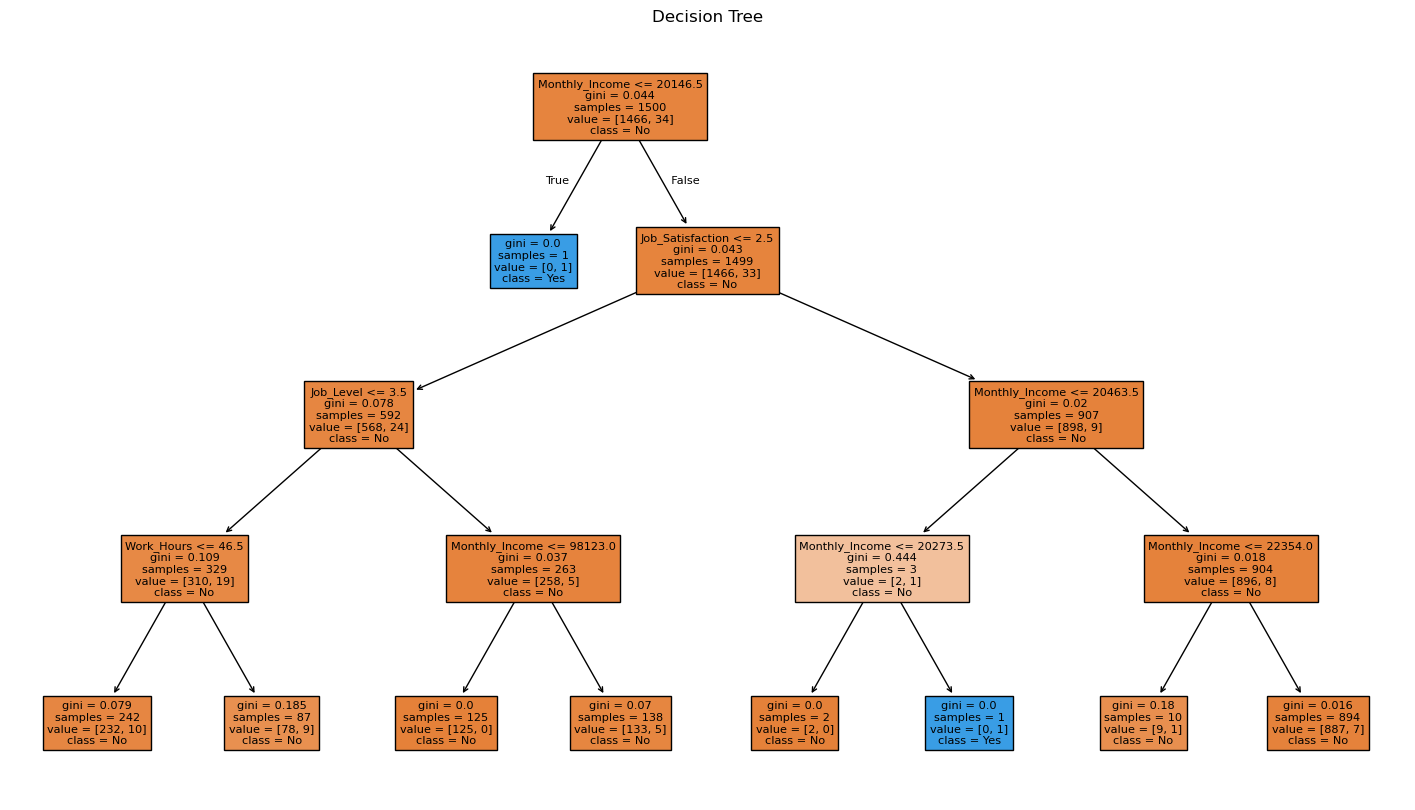

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree 
plt.figure(figsize=(18, 10))
plot_tree(model,feature_names=X.columns,class_names=model.classes_,filled=True)
plt.title("Decision Tree")
plt.show()

**Explanation**

- plot_tree() displays the trained Decision Tree.
- The nodes show the decision conditions.
- The branches show the decision path.
- Leaf nodes show the final prediction.

## **13. How the Tree Arrives at a Prediction**

**Understand the Concept**

- The tree starts from the Root Node.
- It checks the condition at each node.
- Based on the condition, it moves to the next branch.
- It continues until it reaches a Leaf Node.

**How It Works**

- Start at the Root Node.
- Check the feature condition.
- Move left or right based on the result.
- The Leaf Node gives the final prediction.

**Example**

- The tree checks Job_Satisfaction and then Overtime.
- After following the branches, it predicts Attrition as Yes or No.

In [15]:
model = DecisionTreeClassifier(max_depth=4,random_state=42)
model.fit(X, y)
new_employee = [[30, 40000, 2, 2, 50, 1, 15, 20]]
prediction = model.predict(new_employee)
print("Predicted Attrition:", prediction[0])

Predicted Attrition: No


C:\Users\iamna\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


**Explanation**

- The new employee is passed through the tree.
- The tree follows the conditions at each node.
- The final leaf gives the prediction.